<div style="font-size:2em; font-weight:700;">Evaluation Results</div>


This notebook summarizes evaluation outputs for the healthcare client project:
1. **Best Models for each Agent**, plus **Overall Composite Eval Score and P50 latency** for the selected models.
2. **All Evaluated Agent/Model Tuples** (table + chart).
3. **Result interpretation notes** for the current dataset and scoring coverage.


Python below loads results data from `outputs` folder to generate charts and tables (see below for charts and tables)...

In [9]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

root = Path.cwd()
if not (root / 'outputs').exists() and (root.parent / 'outputs').exists():
    root = root.parent

summary_path = root / 'outputs' / 'agent_model_summary.csv'
scored_path = root / 'outputs' / 'results_scored.csv'

summary_df = pd.read_csv(summary_path)
scored_df = pd.read_csv(scored_path)

for col in ['eval_score', 'avg_input_tokens', 'avg_output_tokens', 'p50_latency_ms', 'n_rows', 'n_scored']:
    if col in summary_df.columns:
        summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

for col in ['latency_ms', 'macros_score_0_100', 'ingredients_accuracy_0_100', 'text_quality_0_100', 'meal_composite_0_100']:
    if col in scored_df.columns:
        scored_df[col] = pd.to_numeric(scored_df[col], errors='coerce')

# Recommended architecture from tested models:
# choose highest eval_score per agent.
weights = {'inputGuardrail': 0.20, 'mealAnalysis': 0.50, 'outputGuardrail': 0.30}

recommended = (
    summary_df.sort_values(['agent', 'eval_score'], ascending=[True, False])
    .groupby('agent', as_index=False)
    .first()[['agent', 'model', 'eval_score', 'p50_latency_ms', 'n_rows', 'n_scored']]
)
recommended_models = dict(zip(recommended['agent'], recommended['model']))

# Composite eval score (20/50/30) for the recommended architecture
composite_score = 0.0
weight_sum = 0.0
for agent, w in weights.items():
    row = recommended[recommended['agent'] == agent]
    if len(row) == 0 or pd.isna(row['eval_score'].iloc[0]):
        continue
    composite_score += w * float(row['eval_score'].iloc[0])
    weight_sum += w
composite_score = round(composite_score / weight_sum, 2) if weight_sum else np.nan

# P50 end-to-end latency:
# For each sample id, sum the latencies of the 3 selected agents, then take P50 across sample ids.
sel = scored_df[scored_df['agent'].isin(weights.keys())].copy()
sel = sel[sel.apply(lambda r: recommended_models.get(r['agent']) == r['model'], axis=1)]

lat_pivot = sel.pivot_table(index='id', columns='agent', values='latency_ms', aggfunc='mean')
needed_agents = list(weights.keys())
complete = lat_pivot.dropna(subset=needed_agents).copy()
complete['end_to_end_latency_ms'] = complete[needed_agents].sum(axis=1)
p50_end_to_end_ms = round(float(complete['end_to_end_latency_ms'].median()), 2) if len(complete) else np.nan

metrics_table = pd.DataFrame([
    {'Metric': 'Composite Eval Score (0-100)', 'Value': composite_score},
    {'Metric': 'P50 End-to-End Latency (ms)', 'Value': p50_end_to_end_ms},
    {'Metric': 'Complete samples used for E2E P50', 'Value': len(complete)},
])


### Best Performing Models
The best performing models are `gpt-4.1-mini`, `gpt-4.1`, `gpt-4.1-nano` for inputGuardrail, mealAnalysis, outputGuardrail agents, respectively.

For these best models, there is Composite Eval Score and P50 End-to-End Latency (best model for each agent) below

In [10]:
recommended_display = recommended.rename(columns={'model': 'best_model'})
display(recommended_display.sort_values('agent').reset_index(drop=True).round(2))
display(metrics_table)


,agent,best_model,eval_score,p50_latency_ms,n_rows,n_scored
0,inputGuardrail,gpt-4.1-mini,95.83,1234.40,72,72
1,mealAnalysis,gpt-4.1,68.07,6504.48,72,72
2,outputGuardrail,gpt-4.1-nano,37.50,940.99,72,64


,Metric,Value
0,Composite Eval Score (0-100),64.45
1,P50 End-to-End Latency (ms),8609.85
2,Complete samples used for E2E P50,72.00


### Eval Results for ALL models

,agent,model,n_rows,n_scored,eval_score,avg_input_tokens,avg_output_tokens,p50_latency_ms
0,inputGuardrail,gpt-4.1-mini,72,72,95.83,474.00,26.92,1234.40
1,inputGuardrail,gpt-4.1,72,72,93.06,313.00,35.00,1486.26
2,mealAnalysis,gpt-4.1,72,72,68.07,361.00,201.72,6504.48
3,mealAnalysis,gpt-5-mini,72,72,54.18,413.00,837.83,9785.68
4,outputGuardrail,gpt-4.1-nano,72,64,37.50,188.07,71.00,940.99
5,outputGuardrail,gpt-4.1-mini,72,64,4.69,188.07,71.00,1500.94


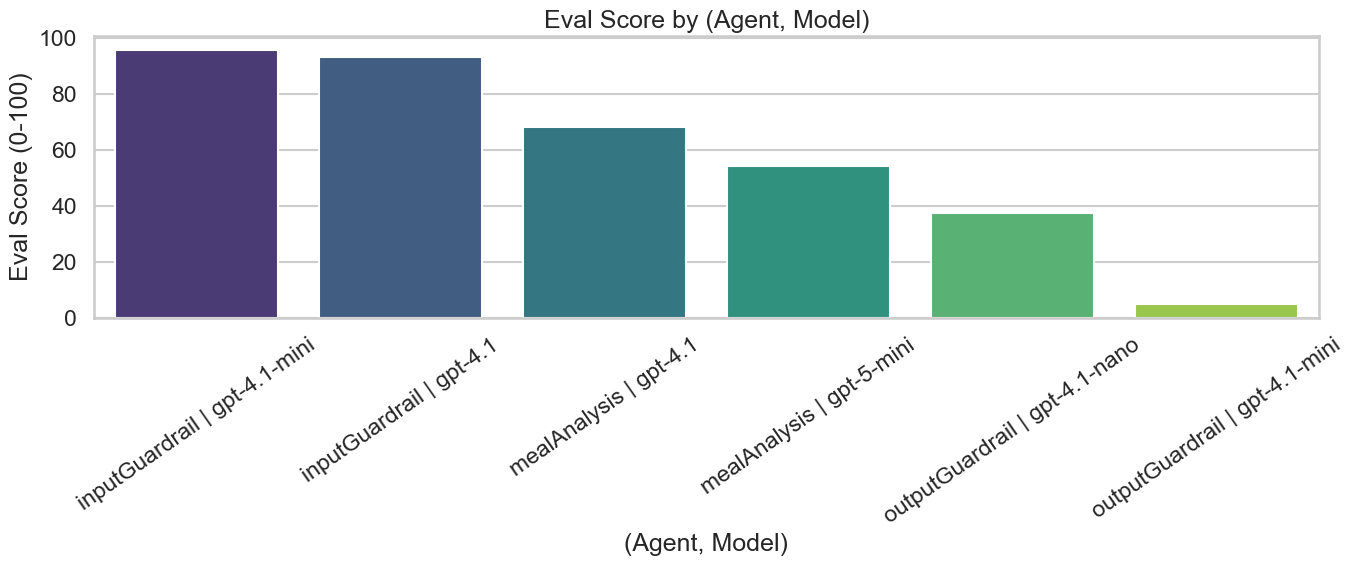

In [3]:
# All scores for all (agent, model) tuples (table + chart)
display(summary_df.sort_values(['agent', 'eval_score'], ascending=[True, False]).reset_index(drop=True).round(2))

plot_df = summary_df.copy()
plot_df['agent_model'] = plot_df['agent'] + ' | ' + plot_df['model']

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_df.sort_values('eval_score', ascending=False), x='agent_model', y='eval_score', hue='agent_model', palette='viridis', dodge=False, ax=ax)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('Eval Score by (Agent, Model)')
ax.set_xlabel('(Agent, Model)')
ax.set_ylabel('Eval Score (0-100)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


### Eval Scores and P50 Latency for ALL models


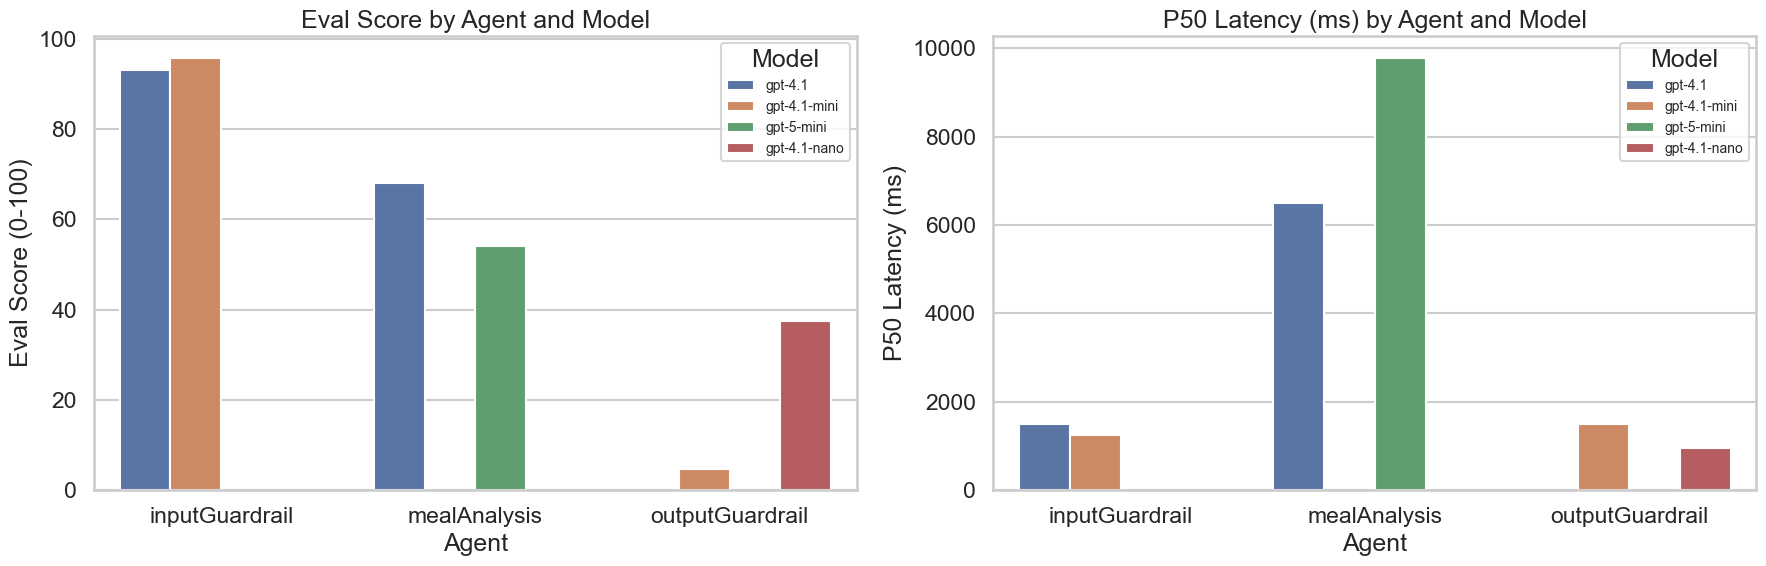

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=summary_df, x='agent', y='eval_score', hue='model', ax=axes[0])
axes[0].set_title('Eval Score by Agent and Model')
axes[0].set_ylabel('Eval Score (0-100)')
axes[0].set_xlabel('Agent')
axes[0].legend(title='Model', fontsize=10)

sns.barplot(data=summary_df, x='agent', y='p50_latency_ms', hue='model', ax=axes[1])
axes[1].set_title('P50 Latency (ms) by Agent and Model')
axes[1].set_ylabel('P50 Latency (ms)')
axes[1].set_xlabel('Agent')
axes[1].legend(title='Model', fontsize=10)

plt.tight_layout()
plt.show()


### Notes on Evaluation Result Interpretation
- The mealAnalysis score is mainly affected by ingredient-level matching quality and recommendation-label misses. Additional model testing can help improve ingredient extraction from images.
- **mealAnalysis is currently the strongest signal** because ground truth for input and output guardrails is incomplete or noisy, so those scores should be interpreted with caution.
